In [1]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

# Allow inline jshtml animations
from matplotlib import rc
rc('animation', html='jshtml')

import anuga

Setting omp_num_threads to 1
Figure files for each frame will be stored in _plot


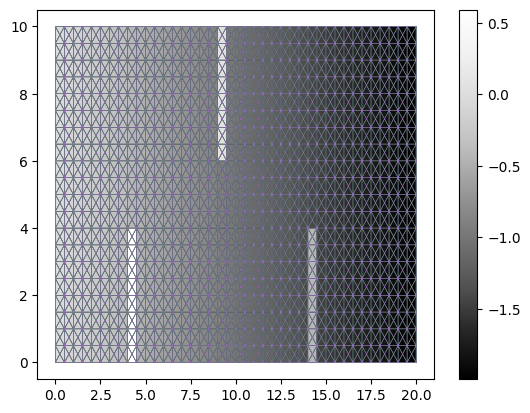

In [8]:
domain = anuga.rectangular_cross_domain(40, 20, len1=20.0, len2=10.0)

domain.set_name('domain1')
domain.set_store_vertices_smoothly(False)

domain.triplot(linewidth = 0.4)
plt.show()

In [3]:
def topography(x, y):

    z = -x/10

    N = len(x)

    minx = np.floor(np.max(x)/4)
    wallx1 = np.min(x[(x >= minx)])
    wallx2 = np.min(x[(x > wallx1 + 0.25)])

    minx = np.floor(np.max(x)/2)
    wallx3 = np.min(x[(x >= minx)])
    wallx4 = np.min(x[(x > wallx3 + 0.25)])

    minx = np.floor(3*np.max(x)/4)
    wallx5 = np.min(x[(x >= minx)])
    wallx6 = np.min(x[(x > wallx5 + 0.25)])

    dist = 0.4 * (np.max(y) - np.min(y))

    for i in range(N):
        if wallx1 <= x[i] <= wallx2:
            if (y[i] < dist):
                z[i] += 1

        if wallx3 <= x[i] <= wallx4:
            if (y[i] > np.max(y) - dist):
                z[i] += 1

        if wallx5 <= x[i] <= wallx6:
            if (y[i] < dist):
                z[i] += 1

    return z

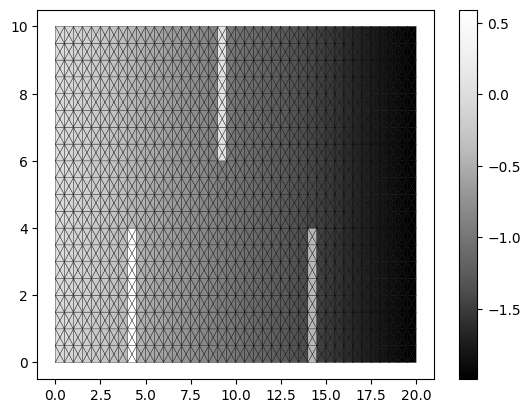

In [9]:
domain.set_quantity('elevation', topography, location='centroids')         # Use function for elevation
domain.set_quantity('friction', 0.01, location='centroids')                # Constant friction
domain.set_quantity('stage', expression='elevation', location='centroids') # Dry Bed

domain.tripcolor(
              facecolors = domain.elev,
              edgecolors='k',
              cmap='Greys_r')
plt.colorbar();
plt.show()

In [5]:
Bi = anuga.Dirichlet_boundary([0.4, 0, 0])         # Inflow
Bo = anuga.Dirichlet_boundary([-2, 0, 0])          # Outflow
Br = anuga.Reflective_boundary(domain)            # Solid reflective wall

domain.set_boundary({'left': Bi, 'right': Bo, 'top': Br, 'bottom': Br})

In [6]:
for t in domain.evolve(yieldstep=2, duration=40):

    #domain.plot_depth_frame()
    domain.save_depth_frame(vmin=0.0,vmax=1.0)

    domain.print_timestepping_statistics()


# Read in the png files stored during the evolve loop
domain.make_depth_animation()

Time = 0.0000 (sec), steps=0 (24s)
Time = 2.0000 (sec), delta t in [0.01779464, 0.03749219] (s), steps=93 (0s)
Time = 4.0000 (sec), delta t in [0.01523410, 0.01780455] (s), steps=123 (0s)
Time = 6.0000 (sec), delta t in [0.01509139, 0.01543878] (s), steps=132 (0s)
Time = 8.0000 (sec), delta t in [0.01543945, 0.01589701] (s), steps=129 (0s)
Time = 10.0000 (sec), delta t in [0.01510457, 0.01595656] (s), steps=129 (0s)
Time = 12.0000 (sec), delta t in [0.01448747, 0.01510270] (s), steps=136 (0s)
Time = 14.0000 (sec), delta t in [0.01416889, 0.01448641] (s), steps=140 (0s)
Time = 16.0000 (sec), delta t in [0.01390842, 0.01416679] (s), steps=143 (0s)
Time = 18.0000 (sec), delta t in [0.01381293, 0.01390783] (s), steps=145 (0s)
Time = 20.0000 (sec), delta t in [0.01356459, 0.01381284] (s), steps=147 (0s)
Time = 22.0000 (sec), delta t in [0.01337491, 0.01356424] (s), steps=149 (0s)
Time = 24.0000 (sec), delta t in [0.01312175, 0.01337337] (s), steps=152 (0s)
Time = 26.0000 (sec), delta t in [